In [2]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import os
import json
import re
from collections import Counter

from atomica.models import MultiClassClassifierModel
from atomica.data.dataset import MultiClassLabelledPDBDataset
from torch.utils.data import DataLoader
from atomica.trainers import Trainer
import torch


def get_best_ckpt(ckpt_dir):
    with open(os.path.join(ckpt_dir, "checkpoint", "topk_map.txt"), "r") as f:
        best_ckpt = f.readlines()[0].strip()
    val_metric, ckpt_path = best_ckpt.split(": ")
    return float(val_metric), ckpt_path

run_name_pat = re.compile(r"dataset\d+_round3_lr3e-5_wd0\.001_drop0\.1_weighted_loss")

prefix = "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_"
checkpoint_dirs = [f'{prefix}{i}' for i in range(139, 256)]

checkpoint_val_results = []
for ckpt_dir in tqdm(checkpoint_dirs, total=len(checkpoint_dirs), desc="Processing checkpoints"):
    args_path = os.path.join(ckpt_dir, "args.json")
    if os.path.exists(args_path):
        with open(args_path, "r") as f:
            args = json.load(f)
        if "_round4_" in args.get('run_name', ''): #or run_name_pat.fullmatch(args.get('run_name', '')):
            val_metric, ckpt_path = get_best_ckpt(ckpt_dir)
            checkpoint_val_results.append({
                "val_metric": val_metric,
                "ckpt_path": ckpt_path,
                "run_name": args['run_name'],
                "dataset": int(args['train_set'].split("/")[-1].split("_")[3].split("A")[0]),
            })
checkpoint_val_results_df = pd.DataFrame(checkpoint_val_results).sort_values(by="val_metric", ascending=False).reset_index(drop=True)
checkpoint_val_results_df['version_epoch'] = checkpoint_val_results_df['ckpt_path'].str[len(prefix):]

Processing checkpoints: 100%|██████████| 117/117 [00:00<00:00, 752.55it/s]


In [3]:
checkpoint_val_results_df['dataset'].value_counts()

dataset
8    25
Name: count, dtype: int64

In [4]:
checkpoint_val_results_df[checkpoint_val_results_df['dataset']==8].sort_values(by='val_metric', ascending=False)

,val_metric,ckpt_path,run_name,dataset,version_epoch
0,0.769828,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,dataset8_round4_lr3e-5_wd0.001_drop0.1_weighte...,8,250/checkpoint/epoch204_step15375.ckpt
1,0.764868,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,dataset8_round4_lr3e-5_wd0.001_drop0.1_weighte...,8,235/checkpoint/epoch164_step11880.ckpt
2,0.762022,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,dataset8_round4_lr3e-5_wd0.001_drop0.1_weighte...,8,249/checkpoint/epoch258_step20979.ckpt
3,0.758176,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,dataset8_round4_lr3e-5_wd0.001_drop0.1_weighte...,8,247/checkpoint/epoch273_step21646.ckpt
4,0.754789,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,dataset8_round4_lr3e-5_wd0.001_drop0.1_weighte...,8,231/checkpoint/epoch213_step16692.ckpt
5,0.751757,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,dataset8_round4_lr3e-5_wd0.001_drop0.1_weighte...,8,233/checkpoint/epoch177_step14418.ckpt
6,0.749421,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,dataset8_round4_lr3e-5_wd0.001_drop0.1_weighte...,8,255/checkpoint/epoch249_step17000.ckpt
7,0.749355,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,dataset8_round4_lr3e-5_wd0.001_drop0.1_weighte...,8,234/checkpoint/epoch141_step11644.ckpt
8,0.747595,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,dataset8_round4_lr3e-5_wd0.001_drop0.1_weighte...,8,237/checkpoint/epoch188_step14931.ckpt
9,0.742302,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,dataset8_round4_lr3e-5_wd0.001_drop0.1_weighte...,8,242/checkpoint/epoch148_step10132.ckpt


In [5]:
# keep top 5 per dataset by val_metric (highest)
top5_per_dataset = (
    checkpoint_val_results_df.sort_values(["dataset", "val_metric"], ascending=[True, False])
      .groupby("dataset", as_index=False, group_keys=False)
      .head(5)
      .reset_index(drop=True)
)

In [6]:
top5_per_dataset[top5_per_dataset['dataset']==8]['ckpt_path'].to_list()

['/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_250/checkpoint/epoch204_step15375.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_235/checkpoint/epoch164_step11880.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_249/checkpoint/epoch258_step20979.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_247/checkpoint/epoch273_step21646.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_231/checkpoint/epoch213_step16692.ckpt']

In [7]:
top5_per_dataset.groupby('dataset').agg({'val_metric': ('mean', 'std')})

val_metric          
              mean       std
dataset                     
8         0.761936  0.005833

In [8]:
def get_config_and_weights_path(ckpt_path):
    weights_path = ckpt_path.replace('.ckpt', '.pt')
    config_path = os.path.dirname(ckpt_path) + "/config.json"
    return config_path, weights_path

def get_model(model_config: str, model_checkpoint: str) -> str:
    model = MultiClassClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    return model

def run_model(ckpt_path, split, dist_th):
    config_path, weights_path = get_config_and_weights_path(ckpt_path)
    dataset = MultiClassLabelledPDBDataset(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/masif_ligand_pdbs_{dist_th}A_pocket_only_{split}.parquet")
    model = get_model(config_path, weights_path)
    atomica_preds = []
    model.eval()
    model.to("cuda")
    batch_size = 16
    for i in tqdm(range(0, len(dataset), batch_size), total=len(dataset) // batch_size, desc=f"Processing {dist_th}A"):
        with torch.no_grad():
            batch = [dataset[j] for j in range(i, min(i+batch_size, len(dataset)))]
            batch = MultiClassLabelledPDBDataset.collate_fn(batch)
            batch = Trainer.to_device(batch, "cuda")
            atomica_preds.append(model.infer(batch).cpu().numpy())
    atomica_preds = np.concatenate(atomica_preds)
    atomica_labels = np.array([x['label'] for x in dataset.data])
    pred_indxes = np.argmax(atomica_preds, axis=1)
    df = pd.DataFrame({
        'dist_th': dist_th,
        'id': [x['id'] for x in dataset.data],
        'label': atomica_labels,
        'pred': pred_indxes,
        'pred_probability': [atomica_preds[i] for i in range(len(atomica_preds))],
        'ckpt_path': ckpt_path,
    })
    df.to_parquet(f"{os.path.dirname(ckpt_path)}/test_preds.parquet", index=False)
    return df

In [9]:
test_results = []
for i, row in top5_per_dataset.iterrows():
    print(f"Processing {i+1}/{len(top5_per_dataset)}")
    df = run_model(row['ckpt_path'], "test", row['dataset'])
    accuracy = (df['label'] == df['pred']).mean()
    test_results.append({
        'dataset': row['dataset'],
        'accuracy': accuracy,
        'ckpt_path': row['ckpt_path'],
    })
test_results_df = pd.DataFrame(test_results)

Processing 1/5


/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/overrides.py:110: UserWarning: 'has_cuda' is deprecated, please use 'torch.backends.cuda.is_built()'
  torch.has_cuda,
/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/overrides.py:111: UserWarning: 'has_cudnn' is deprecated, please use 'torch.backends.cudnn.is_available()'
  torch.has_cudnn,
/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/overrides.py:117: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  torch.has_mps,
/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/overrides.py:118: UserWarning: 'has_mkldnn' is deprecated, please use 'torch.backends.mkldnn.is_available()'
  torch.has_mkldnn,
/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`

Processing 2/5


/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
Processing 8A: 30it [00:18,  1.62it/s]                        


Processing 3/5


/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
Processing 8A: 30it [00:18,  1.62it/s]                        


Processing 4/5


/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
Processing 8A: 30it [00:18,  1.62it/s]                        


Processing 5/5


/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
Processing 8A: 30it [00:18,  1.62it/s]                        


In [10]:
test_results_df.groupby('dataset').agg({'accuracy': ('mean', 'std')})

accuracy          
             mean       std
dataset                    
8        0.757602  0.043738

In [13]:
from collections import Counter
import ast
import numpy as np


def _parse_prob(x):
    """Parse a probability vector coming from CSV (often stored as a string)."""
    if isinstance(x, np.ndarray):
        return x.astype(float)
    if isinstance(x, list):
        return np.array(x, dtype=float)
    if isinstance(x, str):
        s = x.strip()
        # e.g. "[0.1, 0.2, 0.3]" (commas) or "[0.1 0.2 0.3]" (spaces)
        if "," in s:
            return np.array(ast.literal_eval(s), dtype=float)
        return np.fromstring(s.strip("[]"), sep=" ")
    return np.array([x], dtype=float)


def _mean_prob(series):
    arrs = [_parse_prob(v) for v in series]
    return np.vstack(arrs).mean(axis=0)


ensembled_results = []
for dataset in top5_per_dataset['dataset'].unique():
    checkpoints = top5_per_dataset[top5_per_dataset['dataset'] == dataset]['ckpt_path'].tolist()
    all_preds = []
    for i, ckpt_path in enumerate(checkpoints):
        test_results = pd.read_parquet(f"{os.path.dirname(ckpt_path)}/test_preds.parquet")
        test_results['seed'] = i
        all_preds.append(test_results)
    all_preds = pd.concat(all_preds, ignore_index=True)

    # ensemble the predictions per id
    ensembled_preds = (
        all_preds.groupby('id', as_index=False)
        .agg(
            pred_list=('pred', lambda s: s.tolist()),
            pred_probability=('pred_probability', _mean_prob),
            label=('label', 'first'),
        )
    )

    # ensembled_preds['pred'] = ensembled_preds['pred_list'].apply(lambda x: Counter(x).most_common(1)[0][0])
    ensembled_preds['pred'] = ensembled_preds['pred_probability'].apply(lambda x: np.argmax(x))
    ensembled_preds.drop(columns=['pred_list'], inplace=True)

    ensembled_preds['dataset'] = dataset
    ensembled_preds['accuracy'] = (ensembled_preds['label'] == ensembled_preds['pred']).astype(float)

    ensembled_results.append(ensembled_preds)

ensembled_results_df = pd.concat(ensembled_results, ignore_index=True)
ensembled_results_df.groupby('dataset')['accuracy'].agg(['mean'])

,mean
dataset,
8,0.807281


In [50]:
ensembled_results = []
for dataset in top5_per_dataset['dataset'].unique():
    if dataset not in [7,8]:
        continue
    checkpoints = top5_per_dataset[top5_per_dataset['dataset'] == dataset]['ckpt_path'].tolist()
    all_preds = []
    for i, ckpt_path in enumerate(checkpoints):
        test_results = pd.read_csv(f"{os.path.dirname(ckpt_path)}/test_preds.csv")
        test_results['seed'] = i
        all_preds.append(test_results)
    all_preds = pd.concat(all_preds, ignore_index=True)

# ensemble the predictions per id
ensembled_preds = (
    all_preds.groupby('id', as_index=False)
    .agg(
        pred_list=('pred', lambda s: s.tolist()),
        pred_probability=('pred_probability', _mean_prob),
        label=('label', 'first'),
    )
)

ensembled_preds['pred'] = ensembled_preds['pred_probability'].apply(lambda x: np.argmax(x))
ensembled_preds.drop(columns=['pred_list'], inplace=True)
ensembled_preds['accuracy'] = (ensembled_preds['label'] == ensembled_preds['pred']).astype(float)
ensembled_preds['accuracy'].mean()

0.8586723768736617

In [5]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score

def calculate_per_class_metrics(
    y_true,
    y_pred_proba,
    class_names=None,
    f1_mode="argmax",         # "argmax" | "fixed" | "optimal"
    fixed_threshold=0.5
):
    """
    Calculate per-class AUROC, AUPRC, and F1 for multiclass classification.

    Args:
        y_true: array-like of shape (n_samples,), int labels in [0, n_classes-1]
        y_pred_proba: array of shape (n_samples, n_classes), class probabilities
        class_names: optional list of names of length n_classes
        f1_mode:
            - "argmax": derive hard labels via argmax over classes
            - "fixed": per-class one-vs-rest thresholding at `fixed_threshold`
            - "optimal": per-class threshold chosen to maximize F1 on PR curve
        fixed_threshold: threshold used when f1_mode="fixed"
    Returns:
        dict with per-class metrics and macro averages
    """
    y_true = np.asarray(y_true)
    n_classes = y_pred_proba.shape[1]
    if class_names is None:
        class_names = [f"Class_{i}" for i in range(n_classes)]

    # One-vs-rest binarized ground truth
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    results = {}
    thresholds_used = {}

    # If using argmax, compute hard predictions once
    if f1_mode == "argmax":
        y_pred_hard = y_pred_proba.argmax(axis=1)

    for i in range(n_classes):
        cls = class_names[i]

        # skip classes absent in y_true
        if y_true_bin[:, i].sum() == 0:
            results[f"{cls}_AUROC"] = np.nan
            results[f"{cls}_AUPRC"] = np.nan
            results[f"{cls}_F1"] = np.nan
            thresholds_used[cls] = np.nan
            continue

        # AUROC (OvR)
        try:
            results[f"{cls}_AUROC"] = roc_auc_score(y_true_bin[:, i], y_pred_proba[:, i])
        except ValueError:
            results[f"{cls}_AUROC"] = np.nan

        # AUPRC (OvR)
        try:
            precision, recall, pr_thresholds = precision_recall_curve(y_true_bin[:, i], y_pred_proba[:, i])
            results[f"{cls}_AUPRC"] = auc(recall, precision)
        except ValueError:
            precision = recall = pr_thresholds = None
            results[f"{cls}_AUPRC"] = np.nan

        # F1 (choose strategy)
        if f1_mode == "argmax":
            # Standard multiclass F1 computed from hard labels
            f1s = f1_score(y_true, y_pred_hard, average=None, labels=np.arange(n_classes))
            results[f"{cls}_F1"] = f1s[i]
            thresholds_used[cls] = "argmax"
        elif f1_mode == "fixed":
            y_pred_bin_i = (y_pred_proba[:, i] >= fixed_threshold).astype(int)
            results[f"{cls}_F1"] = f1_score(y_true_bin[:, i], y_pred_bin_i)
            thresholds_used[cls] = fixed_threshold
        elif f1_mode == "optimal":
            # pick threshold that maximizes F1 on PR curve
            if precision is None or recall is None or pr_thresholds is None:
                results[f"{cls}_F1"] = np.nan
                thresholds_used[cls] = np.nan
            else:
                # precision, recall length = len(thresholds)+1; align by dropping first point
                pr_thresholds_full = np.r_[[-np.inf], pr_thresholds]  # sentinel to align lengths
                f1_vals = 2 * precision * recall / (precision + recall + 1e-12)
                best_idx = np.nanargmax(f1_vals)
                best_thresh = pr_thresholds_full[best_idx]
                # For sentinel (−inf), fall back to min prob − eps to classify almost all as positive
                if np.isneginf(best_thresh):
                    best_thresh = y_pred_proba[:, i].min() - 1e-12
                y_pred_bin_i = (y_pred_proba[:, i] >= best_thresh).astype(int)
                results[f"{cls}_F1"] = f1_score(y_true_bin[:, i], y_pred_bin_i)
                thresholds_used[cls] = float(best_thresh)
        else:
            raise ValueError("f1_mode must be 'argmax', 'fixed', or 'optimal'.")

    # Macro averages (ignore NaNs)
    auroc_vals = [v for k, v in results.items() if k.endswith("_AUROC") and not np.isnan(v)]
    auprc_vals = [v for k, v in results.items() if k.endswith("_AUPRC") and not np.isnan(v)]
    f1_vals = [v for k, v in results.items() if k.endswith("_F1")    and not np.isnan(v)]

    results["Macro_Avg_AUROC"] = np.mean(auroc_vals) if auroc_vals else np.nan
    results["Macro_Avg_AUPRC"] = np.mean(auprc_vals) if auprc_vals else np.nan
    results["Macro_Avg_F1"] = np.mean(f1_vals) if f1_vals else np.nan
    results["Micro_Avg_F1"] = f1_score(y_true, y_pred_hard, average='micro')
    results["_thresholds_used"] = thresholds_used  # optional: helpful for debugging

    return results

In [6]:
df

,dist_th,id,label,pred,pred_probability,ckpt_path
0,8,4CRM_PX_P_ADP,0,0,"[0.9827886, 0.013071982, 5.958369e-12, 1.23077...",/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...
1,8,3KB1_AB_B_ADP,0,0,"[0.97225565, 0.02524592, 8.198841e-12, 2.35194...",/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...
2,8,3KB1_AB_A_ADP,0,0,"[0.94956434, 0.006606742, 9.665151e-10, 0.0002...",/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...
3,8,4HLU_AD_D_ADP,0,0,"[0.9490975, 0.04924501, 1.1920643e-11, 3.30107...",/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...
4,8,4HLU_AD_A_ADP,0,0,"[0.9849797, 0.009809164, 5.900415e-12, 1.08907...",/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...
...,...,...,...,...,...,...
462,8,4M7T_A_A_SAM,6,4,"[0.002141077, 8.7145656e-07, 5.041055e-07, 1.1...",/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...
463,8,1JG4_A_A_SAM,6,6,"[3.8147984e-08, 2.3922387e-13, 1.9087164e-11, ...",/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...
464,8,4NJJ_AB_B_SAM,6,4,"[0.0035750696, 8.50414e-08, 1.8421587e-11, 3.1...",/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...
465,8,4NJJ_AB_A_SAM,6,4,"[0.028618895, 1.4798388e-06, 2.0425618e-11, 2....",/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...


In [ ]:
df['ckpt_path'][0]

array([9.8278862e-01, 1.3071982e-02, 5.9583692e-12, 1.2307764e-05,
       4.1271388e-03, 4.3614085e-11, 9.8792299e-09], dtype=float32)

In [7]:
MASIF_LIGAND_LABELS = ["ADP", "COA", "FAD", "HEM", "NAD", "NAP", "SAM"]

y_true = df['label'].values
pred_proba = np.stack(df['pred_probability'].values)

per_class_results = calculate_per_class_metrics(
    y_true,
    pred_proba,
    class_names=MASIF_LIGAND_LABELS,
    f1_mode="argmax",
)

In [8]:
per_class_results

{'ADP_AUROC': 0.9321976866456362,
 'ADP_AUPRC': 0.9082425251342482,
 'ADP_F1': 0.8484848484848485,
 'COA_AUROC': 0.8486964163655893,
 'COA_AUPRC': 0.6939003769327472,
 'COA_F1': 0.6285714285714286,
 'FAD_AUROC': 0.932793944930184,
 'FAD_AUPRC': 0.831751389940763,
 'FAD_F1': 0.7763157894736842,
 'HEM_AUROC': 0.9844683393070489,
 'HEM_AUPRC': 0.9484713663669834,
 'HEM_F1': 0.8372093023255814,
 'NAD_AUROC': 0.8508934674348209,
 'NAD_AUPRC': 0.5255691078911983,
 'NAD_F1': 0.5050505050505051,
 'NAP_AUROC': 0.9513504718516109,
 'NAP_AUPRC': 0.8037835392952221,
 'NAP_F1': 0.7368421052631579,
 'SAM_AUROC': 0.9742925659472421,
 'SAM_AUPRC': 0.8869741995123896,
 'SAM_F1': 0.8631578947368421,
 'Macro_Avg_AUROC': 0.9249561274974474,
 'Macro_Avg_AUPRC': 0.7998132150105075,
 'Macro_Avg_F1': 0.7422331248437211,
 'Micro_Avg_F1': 0.7687366167023555,
 '_thresholds_used': {'ADP': 'argmax',
  'COA': 'argmax',
  'FAD': 'argmax',
  'HEM': 'argmax',
  'NAD': 'argmax',
  'NAP': 'argmax',
  'SAM': 'argmax'}}

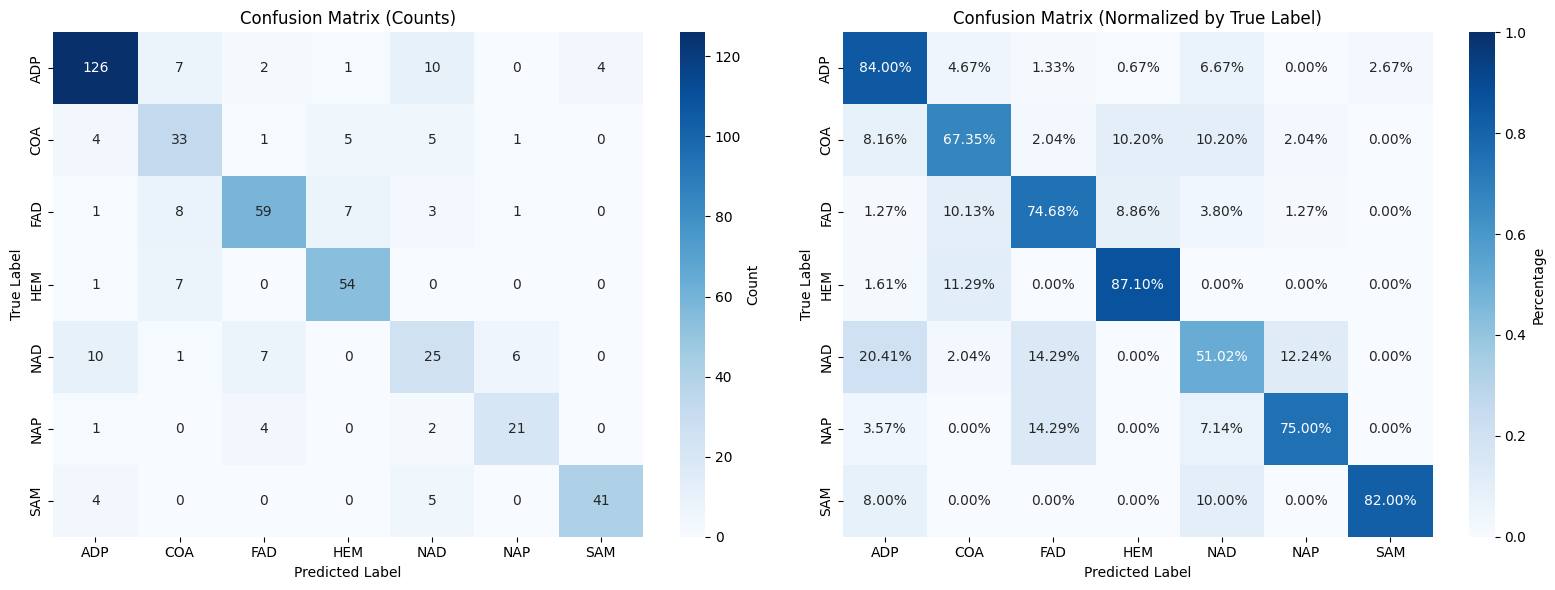


CONFUSION ANALYSIS

ADP (n=150):
  Correct: 126/150 (84.0%)
  Confused with:
    - NAD: 10/150 (6.7%)
    - COA: 7/150 (4.7%)
    - SAM: 4/150 (2.7%)
    - FAD: 2/150 (1.3%)
    - HEM: 1/150 (0.7%)

COA (n=49):
  Correct: 33/49 (67.3%)
  Confused with:
    - HEM: 5/49 (10.2%)
    - NAD: 5/49 (10.2%)
    - ADP: 4/49 (8.2%)
    - FAD: 1/49 (2.0%)
    - NAP: 1/49 (2.0%)

FAD (n=79):
  Correct: 59/79 (74.7%)
  Confused with:
    - COA: 8/79 (10.1%)
    - HEM: 7/79 (8.9%)
    - NAD: 3/79 (3.8%)
    - ADP: 1/79 (1.3%)
    - NAP: 1/79 (1.3%)

HEM (n=62):
  Correct: 54/62 (87.1%)
  Confused with:
    - COA: 7/62 (11.3%)
    - ADP: 1/62 (1.6%)

NAD (n=49):
  Correct: 25/49 (51.0%)
  Confused with:
    - ADP: 10/49 (20.4%)
    - FAD: 7/49 (14.3%)
    - NAP: 6/49 (12.2%)
    - COA: 1/49 (2.0%)

NAP (n=28):
  Correct: 21/28 (75.0%)
  Confused with:
    - FAD: 4/28 (14.3%)
    - NAD: 2/28 (7.1%)
    - ADP: 1/28 (3.6%)

SAM (n=50):
  Correct: 41/50 (82.0%)
  Confused with:
    - NAD: 5/50 (10.0%)
 

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate confusion matrix
y_pred = df['pred'].values
cm = confusion_matrix(y_true, y_pred)

# Calculate normalized confusion matrix (row-wise percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=MASIF_LIGAND_LABELS, 
            yticklabels=MASIF_LIGAND_LABELS,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title('Confusion Matrix (Counts)')

# Plot 2: Normalized percentages
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=MASIF_LIGAND_LABELS,
            yticklabels=MASIF_LIGAND_LABELS,
            ax=axes[1], cbar_kws={'label': 'Percentage'}, vmin=0, vmax=1)
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].set_title('Confusion Matrix (Normalized by True Label)')

plt.tight_layout()
plt.show()

# Print detailed confusion analysis for each class
print("\n" + "="*80)
print("CONFUSION ANALYSIS")
print("="*80)

for i, true_label in enumerate(MASIF_LIGAND_LABELS):
    total = cm[i].sum()
    correct = cm[i, i]
    incorrect = total - correct
    
    print(f"\n{true_label} (n={total}):")
    print(f"  Correct: {correct}/{total} ({100*correct/total:.1f}%)")
    
    if incorrect > 0:
        print(f"  Confused with:")
        # Get indices of confused predictions sorted by count
        confused_indices = [(j, cm[i, j]) for j in range(len(MASIF_LIGAND_LABELS)) if i != j and cm[i, j] > 0]
        confused_indices.sort(key=lambda x: x[1], reverse=True)
        
        for j, count in confused_indices:
            print(f"    - {MASIF_LIGAND_LABELS[j]}: {count}/{total} ({100*count/total:.1f}%)")

In [34]:
def find_optimal_thresholds_multiclass(y_true, y_pred_proba, class_names, metric='f1'):
    """
    Find optimal per-class thresholds for multiclass classification.
    
    Strategy:
    1. For each class, find threshold that maximizes F1 in one-vs-rest setting
    2. Apply thresholds with conflict resolution:
       - If multiple classes exceed threshold: pick highest probability
       - If no classes exceed threshold: pick highest probability (argmax)
    
    Args:
        y_true: ground truth labels
        y_pred_proba: predicted probabilities (n_samples, n_classes)
        class_names: list of class names
        metric: 'f1', 'precision', or 'recall' to optimize
    
    Returns:
        optimal_thresholds: dict mapping class_name -> threshold
    """
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import precision_recall_curve, f1_score
    
    n_classes = y_pred_proba.shape[1]
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))
    
    optimal_thresholds = {}
    
    for i, cls in enumerate(class_names):
        # Get precision-recall curve for this class (one-vs-rest)
        precision, recall, thresholds = precision_recall_curve(y_true_bin[:, i], y_pred_proba[:, i])
        
        # Calculate F1 for each threshold
        # Note: precision/recall arrays are 1 element longer than thresholds
        f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
        
        if metric == 'f1':
            scores = f1_scores
        elif metric == 'precision':
            scores = precision[:-1]
        elif metric == 'recall':
            scores = recall[:-1]
        else:
            raise ValueError(f"Unknown metric: {metric}")
        
        # Find threshold that maximizes the metric
        best_idx = np.argmax(scores)
        optimal_thresholds[cls] = thresholds[best_idx]
        
        print(f"{cls}: optimal_threshold={optimal_thresholds[cls]:.4f}, "
              f"F1={f1_scores[best_idx]:.4f}, "
              f"Precision={precision[best_idx]:.4f}, "
              f"Recall={recall[best_idx]:.4f}")
    
    return optimal_thresholds


def predict_with_thresholds(y_pred_proba, thresholds, class_names):
    """
    Apply per-class thresholds to make predictions.
    
    Conflict resolution:
    - If multiple classes exceed threshold: pick class with highest probability
    - If no classes exceed threshold: pick class with highest probability (standard argmax)
    
    Args:
        y_pred_proba: predicted probabilities (n_samples, n_classes)
        thresholds: dict mapping class_name -> threshold, or list of thresholds
        class_names: list of class names
    
    Returns:
        y_pred: predicted class indices
    """
    n_samples = y_pred_proba.shape[0]
    n_classes = y_pred_proba.shape[1]
    
    # Convert thresholds dict to array
    if isinstance(thresholds, dict):
        threshold_array = np.array([thresholds[cls] for cls in class_names])
    else:
        threshold_array = np.array(thresholds)
    
    y_pred = np.zeros(n_samples, dtype=int)
    
    for i in range(n_samples):
        # Check which classes exceed their thresholds
        above_threshold = y_pred_proba[i] >= threshold_array
        
        if above_threshold.any():
            # If any class exceeds threshold, pick the one with highest probability among them
            masked_probs = np.where(above_threshold, y_pred_proba[i], -np.inf)
            y_pred[i] = np.argmax(masked_probs)
        else:
            # If no class exceeds threshold, fall back to argmax
            y_pred[i] = np.argmax(y_pred_proba[i])
    
    return y_pred

In [35]:
# Step 1: Get predictions on VALIDATION set to find optimal thresholds
# NOTE: Replace with your best checkpoint path
dist_th = 8
split = "val"  # Use validation set!

ckpt_path = checkpoint_val_results_df.iloc[1]['ckpt_path']
df_val = run_model(ckpt_path, split, dist_th)

y_true_val = df_val['label'].values
pred_proba_val = np.stack(df_val['pred_probability'].values)

print("="*80)
print("FINDING OPTIMAL THRESHOLDS ON VALIDATION SET")
print("="*80)

# Find optimal thresholds using validation set
optimal_thresholds = find_optimal_thresholds_multiclass(
    y_true_val, 
    pred_proba_val, 
    MASIF_LIGAND_LABELS,
    metric='f1'  # Can also use 'precision' or 'recall'
)

/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
Processing 8A: 13it [00:11,  1.17it/s]                        

FINDING OPTIMAL THRESHOLDS ON VALIDATION SET
ADP: optimal_threshold=0.3169, F1=0.8723, Precision=0.8542, Recall=0.8913
COA: optimal_threshold=0.7067, F1=0.9231, Precision=1.0000, Recall=0.8571
FAD: optimal_threshold=0.9138, F1=0.8400, Precision=0.8400, Recall=0.8400
HEM: optimal_threshold=0.8990, F1=0.9355, Precision=0.9062, Recall=0.9667
NAD: optimal_threshold=0.5374, F1=0.7000, Precision=0.6562, Recall=0.7500
NAP: optimal_threshold=0.0660, F1=0.6122, Precision=0.6818, Recall=0.5556
SAM: optimal_threshold=0.9616, F1=0.7879, Precision=0.9286, Recall=0.6842


In [36]:
# Step 2: Apply optimal thresholds to TEST set
y_true_test = df['label'].values  # Using the test set df from earlier
pred_proba_test = np.stack(df['pred_probability'].values)

# Make predictions with thresholds
y_pred_threshold = predict_with_thresholds(pred_proba_test, optimal_thresholds, MASIF_LIGAND_LABELS)
y_pred_argmax = df['pred'].values  # Original argmax predictions

print("\n" + "="*80)
print("COMPARISON: ARGMAX vs THRESHOLD-BASED PREDICTIONS")
print("="*80)

from sklearn.metrics import classification_report

print("\n--- Original (Argmax) ---")
report_argmax = classification_report(y_true_test, y_pred_argmax, target_names=MASIF_LIGAND_LABELS, digits=4)
print(report_argmax)

print("\n--- With Optimal Thresholds ---")
report_threshold = classification_report(y_true_test, y_pred_threshold, target_names=MASIF_LIGAND_LABELS, digits=4)
print(report_threshold)

# Calculate macro F1 improvement
from sklearn.metrics import f1_score
f1_argmax = f1_score(y_true_test, y_pred_argmax, average='macro')
f1_threshold = f1_score(y_true_test, y_pred_threshold, average='macro')

print(f"\nMacro F1 - Argmax: {f1_argmax:.4f}")
print(f"Macro F1 - Thresholds: {f1_threshold:.4f}")
print(f"Improvement: {f1_threshold - f1_argmax:.4f} ({100*(f1_threshold - f1_argmax)/f1_argmax:.2f}%)")


COMPARISON: ARGMAX vs THRESHOLD-BASED PREDICTIONS

--- Original (Argmax) ---
              precision    recall  f1-score   support

         ADP     0.8212    0.8267    0.8239       150
         COA     0.7941    0.5510    0.6506        49
         FAD     0.8205    0.8101    0.8153        79
         HEM     0.7262    0.9839    0.8356        62
         NAD     0.5000    0.4694    0.4842        49
         NAP     0.6667    0.7143    0.6897        28
         SAM     0.8636    0.7600    0.8085        50

    accuracy                         0.7645       467
   macro avg     0.7418    0.7308    0.7297       467
weighted avg     0.7672    0.7645    0.7605       467


--- With Optimal Thresholds ---
              precision    recall  f1-score   support

         ADP     0.8098    0.8800    0.8435       150
         COA     0.9630    0.5306    0.6842        49
         FAD     0.8732    0.7848    0.8267        79
         HEM     0.7407    0.9677    0.8392        62
         NAD     0.48

In [37]:
# Analyze HEM precision and recall
from sklearn.metrics import precision_recall_fscore_support, classification_report

y_pred = df['pred'].values
report = classification_report(y_true, y_pred, target_names=MASIF_LIGAND_LABELS, output_dict=True)

print("Per-class Precision, Recall, F1:")
print("="*60)
for ligand in MASIF_LIGAND_LABELS:
    print(f"{ligand:5s}: Precision={report[ligand]['precision']:.3f}, "
        f"Recall={report[ligand]['recall']:.3f}, "
        f"F1={report[ligand]['f1-score']:.3f}, "
        f"Support={report[ligand]['support']:.0f}")

Per-class Precision, Recall, F1:
ADP  : Precision=0.821, Recall=0.827, F1=0.824, Support=150
COA  : Precision=0.794, Recall=0.551, F1=0.651, Support=49
FAD  : Precision=0.821, Recall=0.810, F1=0.815, Support=79
HEM  : Precision=0.726, Recall=0.984, F1=0.836, Support=62
NAD  : Precision=0.500, Recall=0.469, F1=0.484, Support=49
NAP  : Precision=0.667, Recall=0.714, F1=0.690, Support=28
SAM  : Precision=0.864, Recall=0.760, F1=0.809, Support=50
